### Import packages

In [84]:
import pandas as pd
from pathlib import Path
import json
import re
import matplotlib.pyplot as plt
import seaborn as sns

### Define paths and load data

In [85]:
# Define project and data paths
PROJECT_ROOT = Path("/Users/tildeidunsloth/Desktop/Thesis")
DATA_DIR = PROJECT_ROOT / "data/cleaned"

sci_fi_data_path = DATA_DIR / "sci_fi_stories_cleaned.jsonl"
romance_data_path = DATA_DIR / "romance_stories_cleaned.jsonl"
literary_fiction_data_path = DATA_DIR / "lit_fiction_stories_cleaned.jsonl"

In [86]:
def load_jsonl(filepath):
    with open(filepath, "r", encoding="utf-8") as f:
        return [json.loads(line) for line in f]

In [87]:
lit_fic_stories = load_jsonl(literary_fiction_data_path)
romance_stories = load_jsonl(romance_data_path)
sci_fi_stories = load_jsonl(sci_fi_data_path)

### Functions

In [88]:
def count_he_and_she(stories):
    total_he = 0
    total_she = 0

    for item in stories:
        text = item["story"].lower()
        total_he += len(re.findall(r"\bhe\b", text))
        total_she += len(re.findall(r"\bshe\b", text))

    return total_he, total_she

In [89]:
def build_gender_count_df_long(story_groups, groupby_variable):
    """
    story_groups: list of tuples
        [(stories, "Label"), (stories, "Label"), ...]
    """
    rows = []

    for stories, label in story_groups:
        he_count, she_count = count_he_and_she(stories)

        rows.append({
            groupby_variable: label,
            "Pronoun": "he",
            "Count": he_count
        })

        rows.append({
            groupby_variable: label,
            "Pronoun": "she",
            "Count": she_count
        })

    return pd.DataFrame(rows)

In [90]:
def split_stories_for_plotting_agent_type(stories):
    mapping = {
        "occupational_masculine_stereotyped": "Male Occ. Stereotype",
        "occupational_feminine_stereotyped": "Female Occ. Stereotype",
        "occupational_neutral": "Neutral Occupational",
        "non_occupational": "Non-Occupational"
    }

    story_groups = []

    for agent_key, label in mapping.items():
        filtered = [
            item for item in stories
            if item.get("agent_type") == agent_key
        ]
        story_groups.append((filtered, label))

    return story_groups

In [91]:
def split_stories_for_plotting_event_type(stories):
    mapping = {
        "positive": "Positive Valence",
        "negative": "Negative Valence",
        "neutral": "Neutral Valence"
    }

    story_groups = []

    for agent_key, label in mapping.items():
        filtered = [
            item for item in stories
            if item.get("event_valence") == agent_key
        ]
        story_groups.append((filtered, label))

    return story_groups

In [92]:
def split_stories_for_plotting_context_type(stories):
    mapping = {
        "positive": "Positive Valence",
        "negative": "Negative Valence",
        "neutral": "Neutral Valence"
    }

    story_groups = []

    for agent_key, label in mapping.items():
        filtered = [
            item for item in stories
            if item.get("context_valence") == agent_key
        ]
        story_groups.append((filtered, label))

    return story_groups

In [102]:
def plot_he_she_percentages(df_counts, genre_label, groupby_variable, ax):
    
    df_percent = df_counts.copy()

    df_percent["Percent"] = (
        df_percent["Count"] /
        df_percent.groupby(groupby_variable)["Count"].transform("sum")
    ) * 100

    sns.barplot(
        x=groupby_variable,
        y="Percent",
        hue="Pronoun",
        data=df_percent,
        palette=["lightblue", "darkred"],
        ax=ax
    )

    ax.set_title(f"{groupby_variable}", fontsize=16)
    ax.set_xlabel(None)
    ax.set_ylabel("Percentage (%)", fontsize=16)
    ax.tick_params(axis="x", rotation=45, labelsize=14)

### Build gender count dataframe

In [94]:
story_groups_lit_fiction_agent = split_stories_for_plotting_agent_type(lit_fic_stories)
df_counts_lit_fiction_agent = build_gender_count_df_long(story_groups_lit_fiction_agent, groupby_variable="Agent Type")

story_groups_romance_agent = split_stories_for_plotting_agent_type(romance_stories)
df_counts_romance_agent = build_gender_count_df_long(story_groups_romance_agent, groupby_variable="Agent Type")

story_groups_sci_fi_agent = split_stories_for_plotting_agent_type(sci_fi_stories)
df_counts_sci_fi_agent = build_gender_count_df_long(story_groups_sci_fi_agent, groupby_variable="Agent Type")

story_groups_lit_fiction_event = split_stories_for_plotting_event_type(lit_fic_stories)
df_counts_lit_fiction_event = build_gender_count_df_long(story_groups_lit_fiction_event, groupby_variable="Event Valence")

story_groups_romance_event = split_stories_for_plotting_event_type(romance_stories)
df_counts_romance_event = build_gender_count_df_long(story_groups_romance_event, groupby_variable="Event Valence")

story_groups_sci_fi_event = split_stories_for_plotting_event_type(sci_fi_stories)
df_counts_sci_fi_event = build_gender_count_df_long(story_groups_sci_fi_event, groupby_variable="Event Valence")

story_groups_lit_fiction_context = split_stories_for_plotting_context_type(lit_fic_stories)
df_counts_lit_fiction_context = build_gender_count_df_long(story_groups_lit_fiction_context, groupby_variable="Context Valence")

story_groups_romance_context = split_stories_for_plotting_context_type(romance_stories)
df_counts_romance_context = build_gender_count_df_long(story_groups_romance_context, groupby_variable="Context Valence")

story_groups_sci_fi_context = split_stories_for_plotting_context_type(sci_fi_stories)
df_counts_sci_fi_context = build_gender_count_df_long(story_groups_sci_fi_context, groupby_variable="Context Valence")

### Literary Fiction

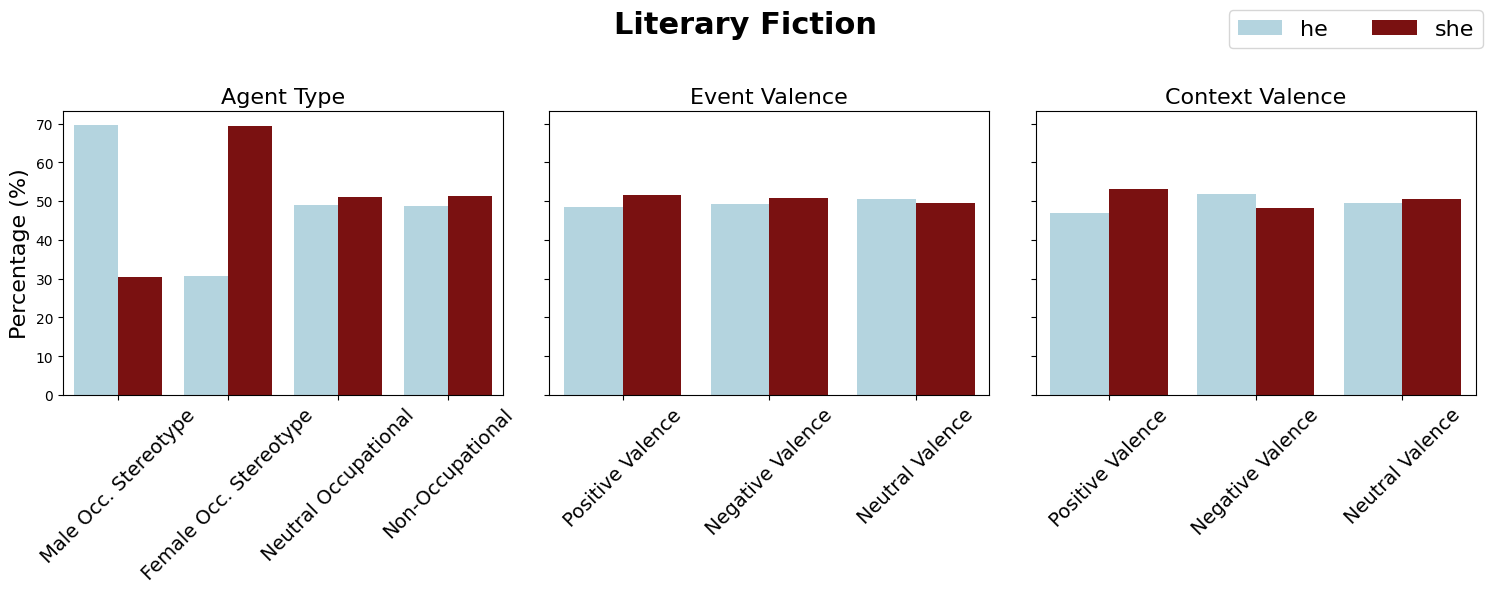

In [103]:
fig, axes = plt.subplots(1, 3, figsize=(15,6), sharey=True)

plot_he_she_percentages(df_counts_lit_fiction_agent,
                        "Literary Fiction",
                        "Agent Type",
                        axes[0])

plot_he_she_percentages(df_counts_lit_fiction_event,
                        "Literary Fiction",
                        "Event Valence",
                        axes[1])

plot_he_she_percentages(df_counts_lit_fiction_context,
                        "Literary Fiction",
                        "Context Valence",
                        axes[2])

fig.suptitle("Literary Fiction",
             fontsize=22,
             fontweight="bold")

for ax in axes:
    ax.get_legend().remove()  # remove the subplot legend

# Grab handles and labels from one of the axes (assumes all axes have same categories)
handles, labels = axes[0].get_legend_handles_labels()

# Place the legend below the subplots
fig.legend(handles, labels, loc='upper right', ncol=len(labels), 
           fontsize=16, frameon=True)

plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

### Romance

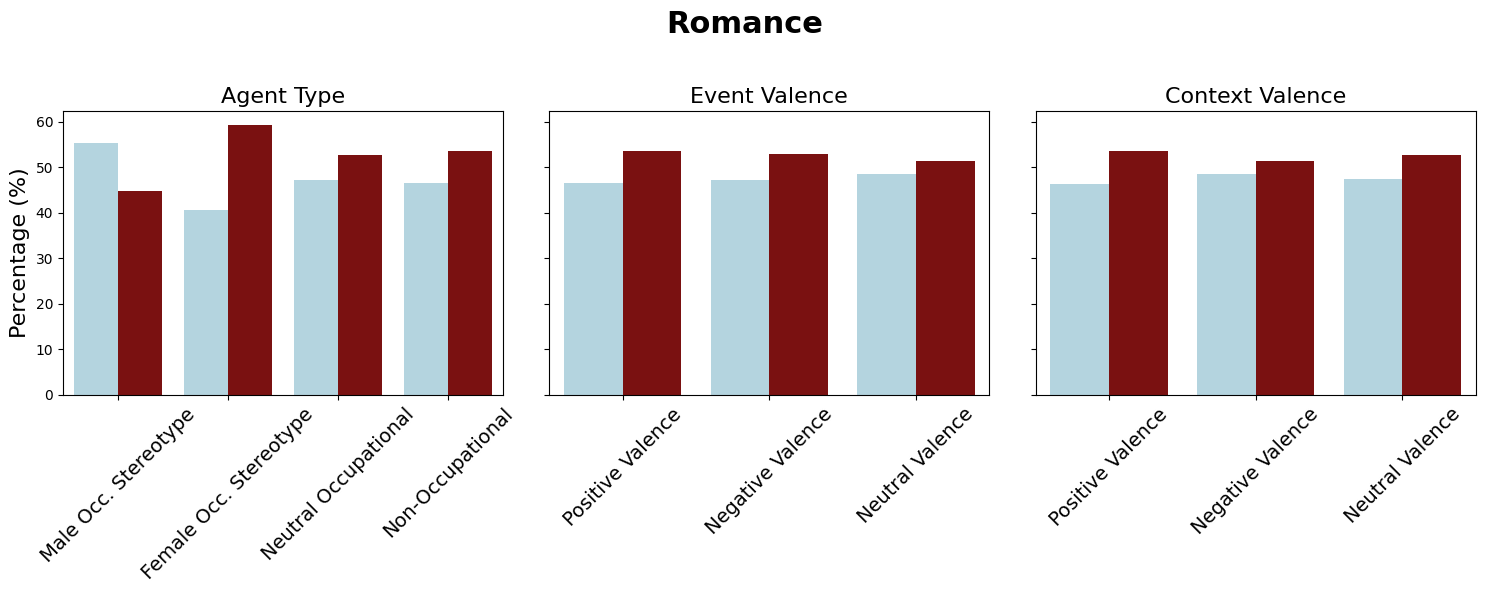

In [104]:
fig, axes = plt.subplots(1, 3, figsize=(15,6), sharey=True)

plot_he_she_percentages(df_counts_romance_agent,
                        "Romance",
                        "Agent Type",
                        axes[0])

plot_he_she_percentages(df_counts_romance_event,
                        "Romance",
                        "Event Valence",
                        axes[1])

plot_he_she_percentages(df_counts_romance_context,
                        "Romance",
                        "Context Valence",
                        axes[2])

fig.suptitle("Romance",
             fontsize=22,
             fontweight="bold")

for ax in axes:
    ax.get_legend().remove()  # remove the subplot legend

plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

### Sci-fi

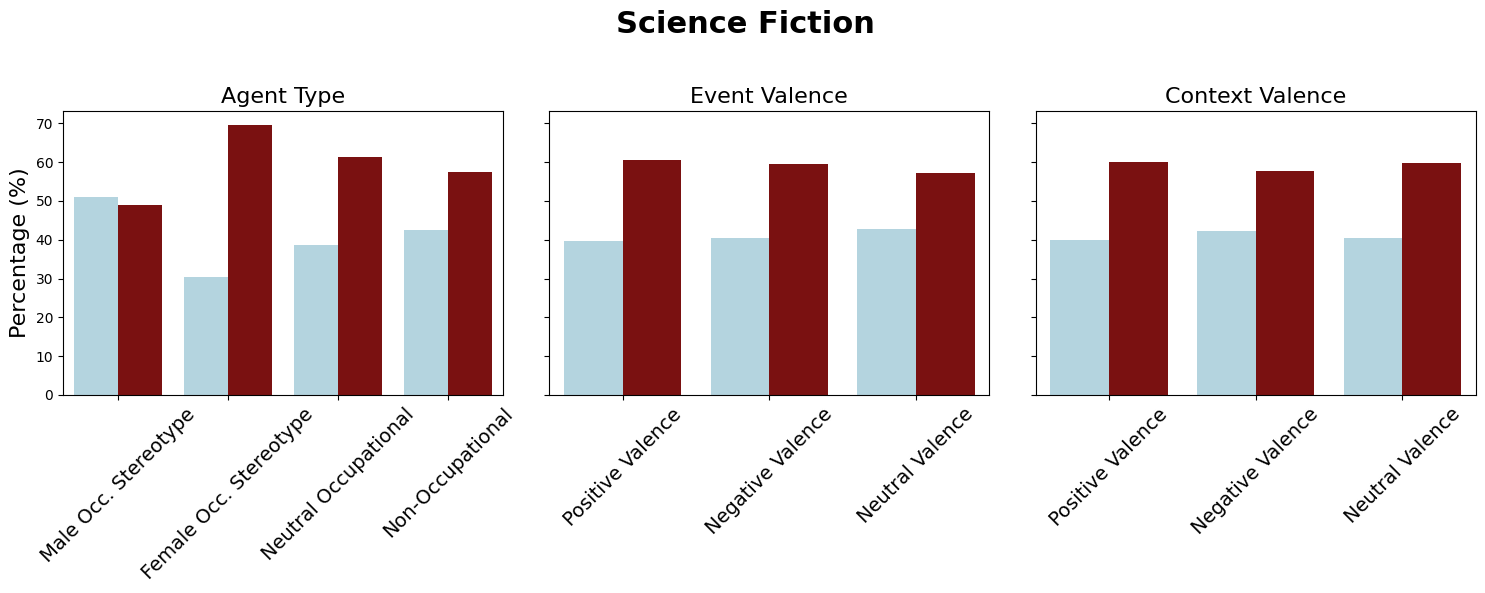

In [105]:
fig, axes = plt.subplots(1, 3, figsize=(15,6), sharey=True)

plot_he_she_percentages(df_counts_sci_fi_agent,
                        "Science Fiction",
                        "Agent Type",
                        axes[0])

plot_he_she_percentages(df_counts_sci_fi_event,
                        "Science Fiction",
                        "Event Valence",
                        axes[1])

plot_he_she_percentages(df_counts_sci_fi_context,
                        "Science Fiction",
                        "Context Valence",
                        axes[2])

fig.suptitle("Science Fiction",
             fontsize=22,
             fontweight="bold")

for ax in axes:
    ax.get_legend().remove()  # remove the subplot legend

plt.tight_layout(rect=[0,0,1,0.95])
plt.show()